In [ ]:
#from a fieldmap in straight coordinates to one in curved coordinates
import numpy as np
import matplotlib.pyplot as plt
from math import factorial
import bpmeth
from sympy import lambdify 
from sympy.abc import x, y, s

(0.0, 1.0)

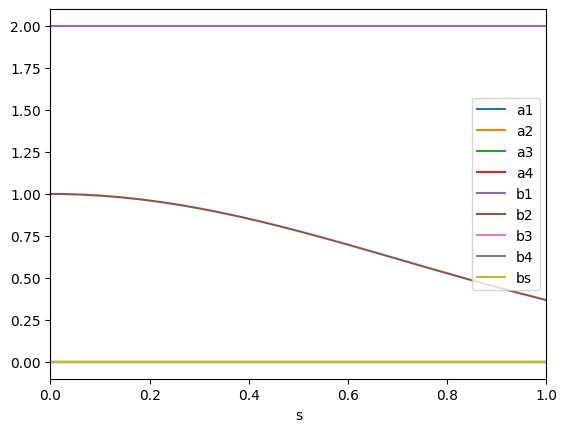

In [ ]:
#start from multipole coeefficients a_n(s)=a1,a2,... and b_n(s)
a_coeffs = [0, 0, 0, 0]
b_coeffs = [2,"exp(-s**2)",0, 0]
#get scalar potential
expansion=bpmeth.FieldExpansion(a=a_coeffs, b=b_coeffs)
expansion.plot_components()
plt.xlabel('s')
plt.xlim((0,1))

Scalar potential phi(x,y,s): -x*y**3*(2*s**2 - 1)*exp(-s**2)/3 + y*(6*x*exp(-s**2) + 12)/6
Scalar potential phi at (0.4,0.2,0.5): 0.46271942306335045


/home/fmarcoli/bpmeth/src/bpmeth/generate_expansion.py:94: UserWarning: More terms are needed in the expansion for aperture 0.05m, the laplacian is -0.0000123442050462438
  warnings.warn(f"More terms are needed in the expansion for aperture {apperture}m, the laplacian is {laplval}")


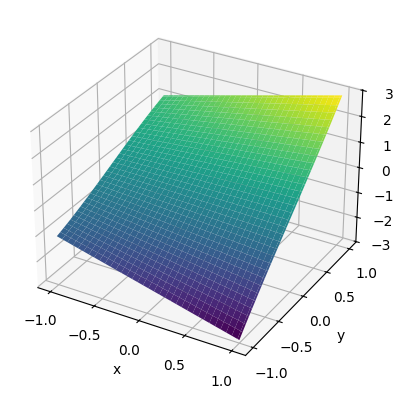

In [ ]:
phi=expansion.get_phi()
print("Scalar potential phi(x,y,s):", phi)

XYS=(x,y,s)#symbolic expressions

phi_func = lambdify(XYS, phi, 'numpy')#from symbolic to numerical function
print("Scalar potential phi at (0.4,0.2,0.5):", phi_func(0.4,0.2,0.5))
#define x,y,s axes to convert the symbolic expression of phi into a numerical array
xa= np.linspace(-1,1,101)
ya=np.linspace(-1,1,101)
sa=np.linspace(-1,1,101)
#make a 3d plot of phi as a function of x and y for a fixed s
X, Y = np.meshgrid(xa, ya)
P = phi_func(X, Y, 0.5)#s=0.5 is the middle  of the magnet
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, P, cmap='viridis')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('phi(x,y,s=0.5)')
plt.show()

In [ ]:
# Get analytical B field functions
Bx_func, By_func, Bs_func = expansion.get_Bfield(lambdify=True)
#print("Bx:", Bx_func, "By:", By_func, "Bs:", Bs_func)
# Evaluate on grid
X,Y,S = np.meshgrid(xa, ya, sa)
Bx_ana = Bx_func(X, Y, S)
By_ana = By_func(X, Y, S)
Bs_ana = Bs_func(X, Y, S)
#print("Bx shape:", Bx_ana.shape, "By shape:", By_ana.shape, "Bs shape:", Bs_ana.shape)
# X, Y, S  from meshgrid in straight frame
# Bx_ana, By_ana, Bs_ana are the corresponding field arrays
datafieldmap = np.column_stack([
    X.ravel(),
    Y.ravel(),
    S.ravel(),
    Bx_ana.ravel(),
    By_ana.ravel(),
    Bs_ana.ravel()
])
#print("Data shape (N, 6):", datafieldmap.shape)
fm = bpmeth.fieldmaps.Fieldmap(datafieldmap)
#print(xa.shape)

In [ ]:
rho = .5
phi = 1.
xFS = np.linspace(-0.05, 0.05, 101)
yFS = np.linspace(-0.05, 0.05, 101)
sFS = np.linspace(-rho*phi, rho*phi, 103)
interp_rad=0.025
fm_fs = fm.calc_FS_coords(xFS, yFS, sFS, rho, phi, radius=interp_rad)

Now I can extract multipole coefficients using harmonic analysis